# IMPORTAZIONI LIBRERIE 

In [55]:
import pandas as pd
import os

import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt

# REVISIONE ED INFO GENERALI SUL DF DI PARTENZA

In [56]:
df=pd.read_csv("df_clean/df_final_from_20_to_24_clean.csv")

print(df.info())
df

<class 'pandas.DataFrame'>
RangeIndex: 113799 entries, 0 to 113798
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   ID_COMUNE         113799 non-null  int64  
 1   DATA_TYPE         113799 non-null  str    
 2   RESULTS           113799 non-null  str    
 3   TIME_PERIOD       113799 non-null  int64  
 4   OBS_VALUE         113799 non-null  int64  
 5   CODICE PROVINCIA  113799 non-null  int64  
 6   COMUNE            113799 non-null  str    
 7   RESIDENTI         113799 non-null  int64  
 8   SUPERFICIE (KMQ)  113799 non-null  float64
dtypes: float64(1), int64(5), str(3)
memory usage: 7.8 MB
None


,ID_COMUNE,DATA_TYPE,RESULTS,TIME_PERIOD,OBS_VALUE,CODICE PROVINCIA,COMUNE,RESIDENTI,SUPERFICIE (KMQ)
0,1001,morti_e_feriti,feriti,2020,4,201,Agliè,2545,13.1462
1,1001,morti_e_feriti,feriti,2021,2,201,Agliè,2545,13.1462
2,1001,morti_e_feriti,feriti,2022,5,201,Agliè,2545,13.1462
3,1001,morti_e_feriti,feriti,2023,6,201,Agliè,2545,13.1462
4,1001,morti_e_feriti,feriti,2024,5,201,Agliè,2545,13.1462
...,...,...,...,...,...,...,...,...,...
113794,111107,incidenti_stradali,incidenti,2020,2,111,Villaspeciosa,2549,27.1937
113795,111107,incidenti_stradali,incidenti,2021,5,111,Villaspeciosa,2549,27.1937
113796,111107,incidenti_stradali,incidenti,2022,1,111,Villaspeciosa,2549,27.1937
113797,111107,incidenti_stradali,incidenti,2023,4,111,Villaspeciosa,2549,27.1937


In [57]:
print(df.isna().sum())
print('----------------')
print(df.duplicated().sum())
print('-------------------------')
print ("Comuni analizzati:", df[df["TIME_PERIOD"]==2020]["ID_COMUNE"].nunique())


ID_COMUNE           0
DATA_TYPE           0
RESULTS             0
TIME_PERIOD         0
OBS_VALUE           0
CODICE PROVINCIA    0
COMUNE              0
RESIDENTI           0
SUPERFICIE (KMQ)    0
dtype: int64
----------------
0
-------------------------
Comuni analizzati: 7903


In [58]:
print(df["DATA_TYPE"].value_counts())
print("--------------------------------------")
print(df["RESULTS"].value_counts())
print("--------------------------------------")
print(df.groupby("RESULTS")["OBS_VALUE"].sum())
print("--------------------------------------")
print(df["TIME_PERIOD"].value_counts()) 

DATA_TYPE
morti_e_feriti        75866
incidenti_stradali    37933
Name: count, dtype: int64
--------------------------------------
RESULTS
feriti       37933
morti        37933
incidenti    37933
Name: count, dtype: int64
--------------------------------------
RESULTS
feriti       1045812
incidenti     775868
morti          14497
Name: OBS_VALUE, dtype: int64
--------------------------------------
TIME_PERIOD
2020    23709
2021    23703
2022    23703
2023    23688
2024    18996
Name: count, dtype: int64


2024    18996 --> può essere perchè non erano state registrate ancora tutte le osservazioni?

# SEPARAZIONE IN DF INCIDENTI-MORTI-FERITI CON ANNUALITA' 20-24 e CREAZIONE NUOVE COLONNE

In [59]:
df_incidenti= df[df["RESULTS"]=="incidenti"]

df_morti= df[df["RESULTS"]=="morti"]

df_feriti= df[df["RESULTS"]=="feriti"]

In [60]:
df_incidenti["INCIDENTI_PRO_CAPITE(1000)"] = (df_incidenti["OBS_VALUE"]/df_incidenti["RESIDENTI"]) * 1000

df_incidenti["DENSITA_INCIDENTI"] = (df_incidenti["OBS_VALUE"]/df_incidenti["SUPERFICIE (KMQ)"])

df_incidenti["DENSITA_POPOLAZIONE"] = (df_incidenti["RESIDENTI"]/df_incidenti["SUPERFICIE (KMQ)"])

df_incidenti.head(10)

,ID_COMUNE,DATA_TYPE,RESULTS,TIME_PERIOD,OBS_VALUE,CODICE PROVINCIA,COMUNE,RESIDENTI,SUPERFICIE (KMQ),INCIDENTI_PRO_CAPITE(1000),DENSITA_INCIDENTI,DENSITA_POPOLAZIONE
10,1001,incidenti_stradali,incidenti,2020,4,201,Agliè,2545,13.1462,1.571709,0.304270,193.592065
11,1001,incidenti_stradali,incidenti,2021,2,201,Agliè,2545,13.1462,0.785855,0.152135,193.592065
12,1001,incidenti_stradali,incidenti,2022,3,201,Agliè,2545,13.1462,1.178782,0.228203,193.592065
13,1001,incidenti_stradali,incidenti,2023,3,201,Agliè,2545,13.1462,1.178782,0.228203,193.592065
14,1001,incidenti_stradali,incidenti,2024,2,201,Agliè,2545,13.1462,0.785855,0.152135,193.592065
25,1002,incidenti_stradali,incidenti,2020,8,201,Airasca,3633,15.7393,2.202037,0.508282,230.823480
26,1002,incidenti_stradali,incidenti,2021,6,201,Airasca,3633,15.7393,1.651528,0.381211,230.823480
27,1002,incidenti_stradali,incidenti,2022,4,201,Airasca,3633,15.7393,1.101018,0.254141,230.823480
28,1002,incidenti_stradali,incidenti,2023,7,201,Airasca,3633,15.7393,1.926782,0.444747,230.823480
29,1002,incidenti_stradali,incidenti,2024,5,201,Airasca,3633,15.7393,1.376273,0.317676,230.823480


In [61]:

# df_comuni_incidenti: -1 riga è 1 anno con relativi dati nel periodo dal 2020 al 2024
# 				       -valori sono distinti per anno
#                      -superficie e residenti si presume siano rimasti costanti in questi 4 anni

df_incidenti.to_csv("df_clean/df_incidenti.csv",index=False)

## ANALISI DESCRITTIVA 

In [62]:
# Top comuni per incidenti per 1000 abitanti ----comuni con incidenti pro capite più alto --> sono i comuni più piccoli
df_incidenti.sort_values(by="INCIDENTI_PRO_CAPITE(1000)",ascending=False).head()

#Top comuni per incidenti per kmq
df_incidenti.sort_values(by="DENSITA_INCIDENTI",ascending=False).head()


,ID_COMUNE,DATA_TYPE,RESULTS,TIME_PERIOD,OBS_VALUE,CODICE PROVINCIA,COMUNE,RESIDENTI,SUPERFICIE (KMQ),INCIDENTI_PRO_CAPITE(1000),DENSITA_INCIDENTI,DENSITA_POPOLAZIONE
25114,15146,incidenti_stradali,incidenti,2023,7812,215,Milano,1374582,181.6783,5.683182,42.999081,7566.021919
25113,15146,incidenti_stradali,incidenti,2022,7783,215,Milano,1374582,181.6783,5.662085,42.839459,7566.021919
25115,15146,incidenti_stradali,incidenti,2024,7743,215,Milano,1374582,181.6783,5.632985,42.619289,7566.021919
25112,15146,incidenti_stradali,incidenti,2021,7465,215,Milano,1374582,181.6783,5.430742,41.089112,7566.021919
24680,15086,incidenti_stradali,incidenti,2024,126,215,Cormano,20317,4.4734,6.201703,28.166495,4541.735593


In [63]:
df_incidenti.describe().round(0)

,ID_COMUNE,TIME_PERIOD,OBS_VALUE,CODICE PROVINCIA,RESIDENTI,SUPERFICIE (KMQ),INCIDENTI_PRO_CAPITE(1000),DENSITA_INCIDENTI,DENSITA_POPOLAZIONE
count,37933.0,37933.0,37933.0,37933.0,37933.0,37933.0,37933.0,37933.0,37933.0
mean,45180.0,2022.0,20.0,77.0,7772.0,39.0,2.0,1.0,309.0
std,32504.0,1.0,185.0,80.0,42706.0,52.0,2.0,2.0,648.0
min,1001.0,2020.0,0.0,2.0,29.0,0.0,0.0,0.0,1.0
25%,16173.0,2021.0,1.0,19.0,1071.0,12.0,1.0,0.0,45.0
50%,40015.0,2022.0,3.0,57.0,2553.0,23.0,1.0,0.0,110.0
75%,72038.0,2023.0,11.0,94.0,6479.0,45.0,2.0,1.0,290.0
max,111107.0,2024.0,13924.0,292.0,2770226.0,1287.0,98.0,43.0,11886.0


In [64]:
df_incidenti["RESIDENTI"].quantile([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])

0.01      116.00
0.05      302.00
0.10      498.00
0.25     1071.00
0.50     2553.00
0.75     6479.00
0.90    14676.00
0.95    25443.00
0.99    72738.12
Name: RESIDENTI, dtype: float64

L'analisi dei percentili della popolazione residente evidenzia una distribuzione fortemente sbilanciata verso i piccoli comuni. 
Il 25% dei comuni presenta meno di 1.071 abitanti, mentre la mediana si attesta a 2.553 abitanti, indicando che metà dei comuni del dataset ha una popolazione inferiore a tale valore. 

Il 75% dei comuni non supera i 6.479 abitanti e solo il 10% supera i 14.676 residenti. 

I valori del 95% non superano i 25.443 e il 99% i 72.738 abitanti, mostrano come una piccola quota di comuni concentri popolazioni molto più elevate rispetto alla maggioranza.

## CORRELAZIONI TRA VARIABILI

In [65]:
corr=df_incidenti[["INCIDENTI_PRO_CAPITE(1000)","RESIDENTI",
                   "SUPERFICIE (KMQ)", "OBS_VALUE", "DENSITA_POPOLAZIONE",
                     "DENSITA_INCIDENTI"]].corr()
corr

,INCIDENTI_PRO_CAPITE(1000),RESIDENTI,SUPERFICIE (KMQ),OBS_VALUE,DENSITA_POPOLAZIONE,DENSITA_INCIDENTI
INCIDENTI_PRO_CAPITE(1000),1.000000,0.087587,0.071469,0.106952,0.051867,0.251753
RESIDENTI,0.087587,1.000000,0.380428,0.963500,0.284838,0.431297
SUPERFICIE (KMQ),0.071469,0.380428,1.000000,0.344060,-0.126102,-0.034655
OBS_VALUE,0.106952,0.963500,0.344060,1.000000,0.225799,0.427036
DENSITA_POPOLAZIONE,0.051867,0.284838,-0.126102,0.225799,1.000000,0.786624
DENSITA_INCIDENTI,0.251753,0.431297,-0.034655,0.427036,0.786624,1.000000


OBS_VALUE - RESIDENTI (0.964): forte correlazione positiva.comuni con molte persone hanno molti incidenti

OBS_VALUE - SUPERFICIE (0.344): correlazione debole

RESIDENTI - SUPERFICIE (0.380): correlazione debole, a conferma che comuni più estesi non sono necessariamente i più popolosi. --> IL MIO DUBBIO INIZIALE E' STATO CONFUTATO, pensavo che + superficie = + persone= + incidenti

DENSITA_POPOLAZIONE - DENSITA_INCIDENTI (0.787): forte correlazione positiva

DENSITA_POPOLAZIONE - INCIDENTI_PRO_CAPITE(1000) (0.052): correlazione praticamente nulla

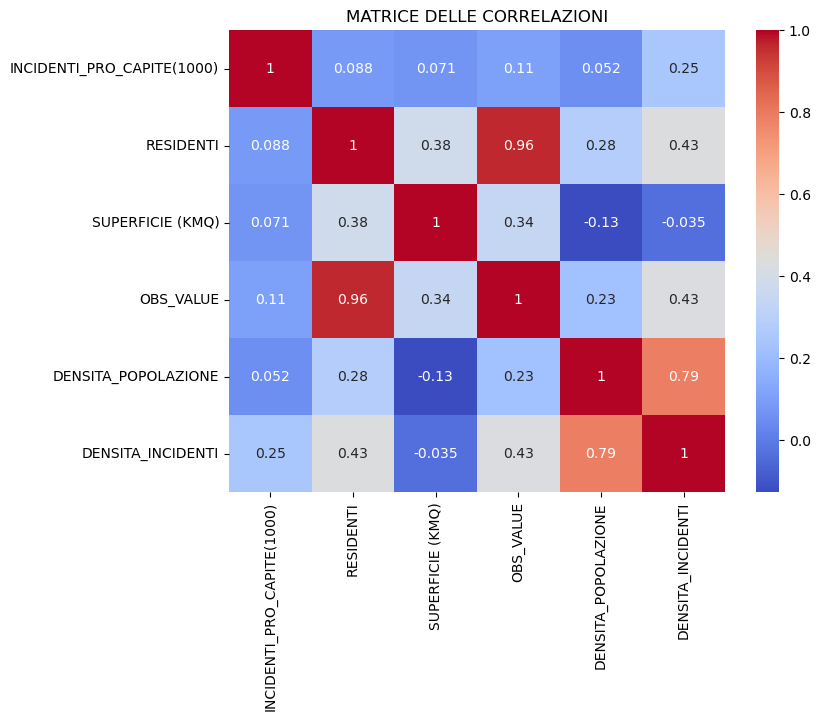

In [66]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr,annot=True,cmap="coolwarm")

plt.title("MATRICE DELLE CORRELAZIONI")
plt.show()

## HISTPLOT E BOXPLOT

Rappresentare graficamente le distribuzioni delle variabili

In [67]:
def plot_distribuzione(df, column):
    fig, ax = plt.subplots(1, 2, figsize=(8, 4))

    sns.histplot(data=df,x=column,bins=20,ax=ax[0]).set_title(f"Istogramma - {column}")

    sns.boxplot(x=df[column],ax=ax[1]).set_title(f"Boxplot - {column}")

    plt.tight_layout()
    plt.show()

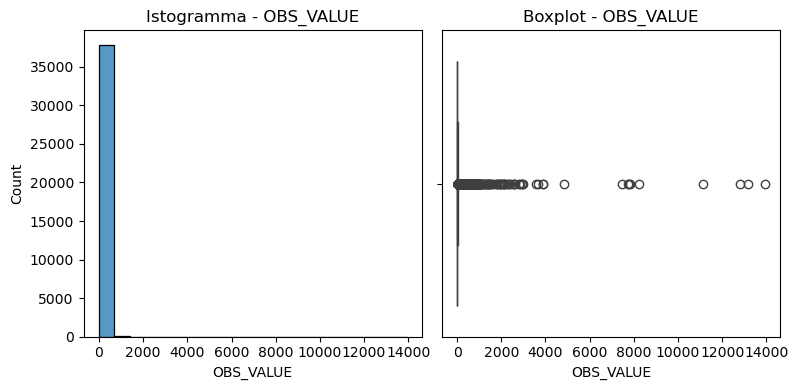

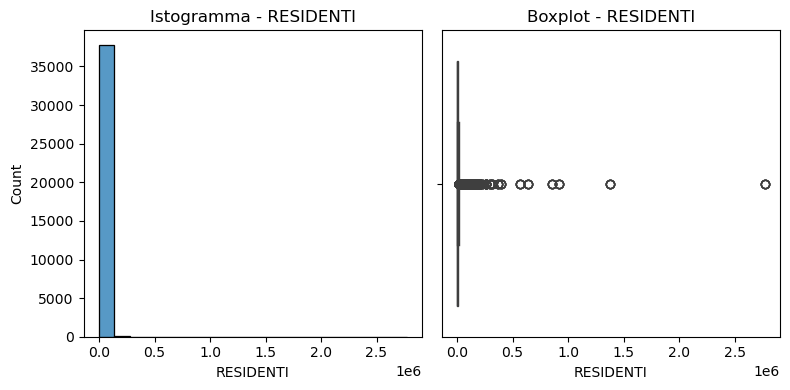

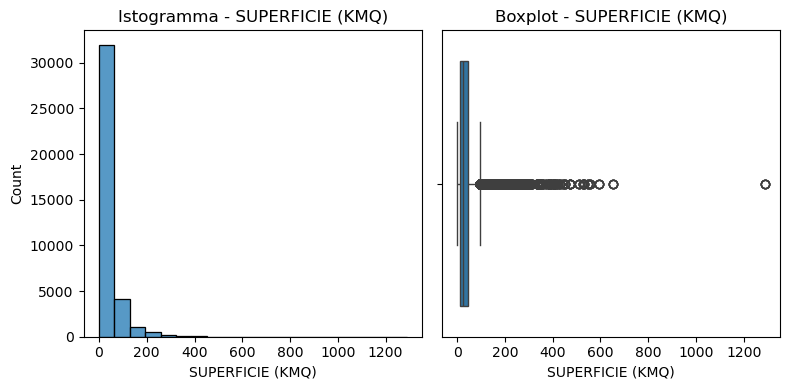

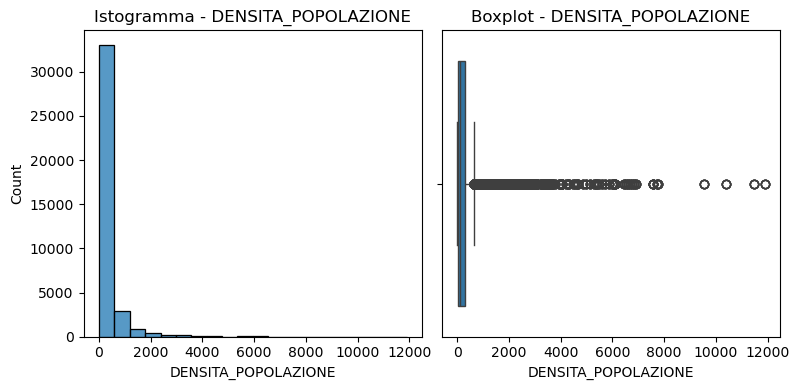

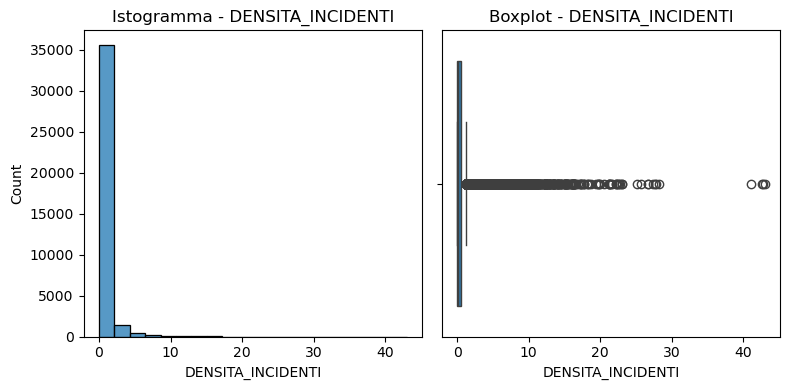

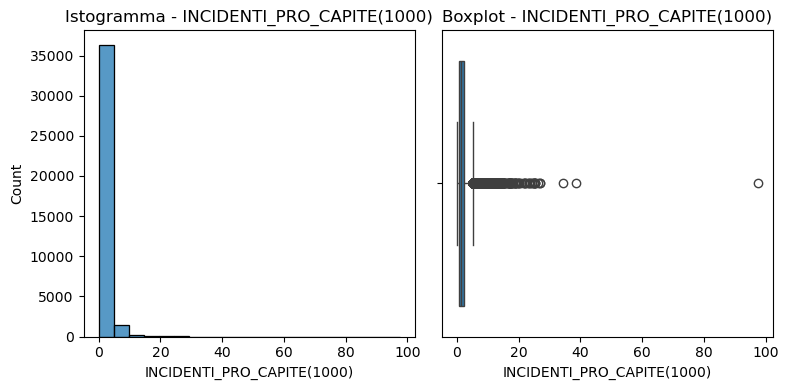

In [68]:
plot_distribuzione(df_incidenti, "OBS_VALUE")
plot_distribuzione(df_incidenti, "RESIDENTI")
plot_distribuzione(df_incidenti, "SUPERFICIE (KMQ)")
plot_distribuzione(df_incidenti, "DENSITA_POPOLAZIONE")
plot_distribuzione(df_incidenti, "DENSITA_INCIDENTI")
plot_distribuzione(df_incidenti, "INCIDENTI_PRO_CAPITE(1000)")

## SCATTERPLOT

L' intento è quello di osservare graficamente l' andamento delle correlazioni tra le variabili prese in esame

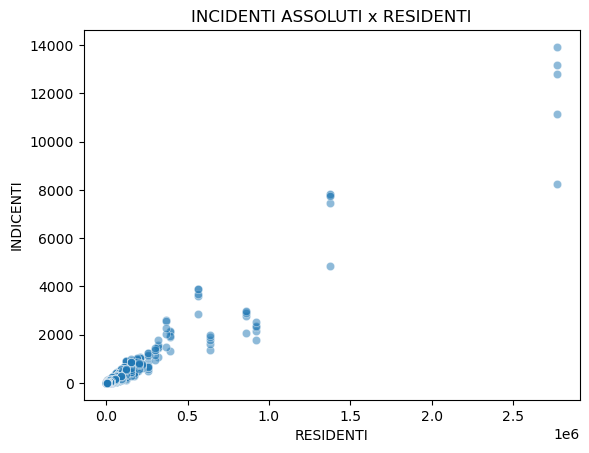

In [69]:
sns.scatterplot(data=df_incidenti,x="RESIDENTI",y="OBS_VALUE", alpha=0.5)
plt.title("INCIDENTI ASSOLUTI x RESIDENTI")
plt.ylabel("INDICENTI")
plt.show()

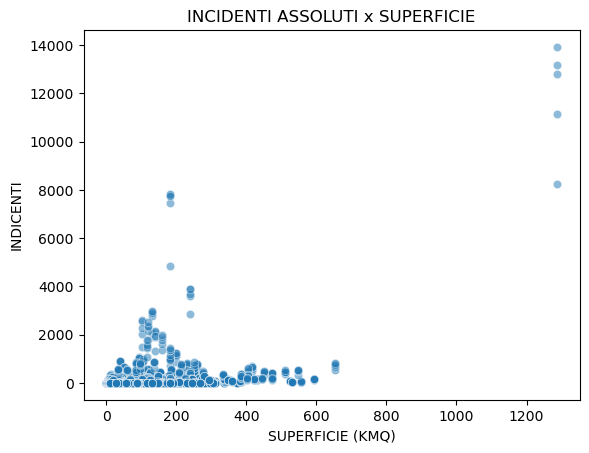

In [70]:
sns.scatterplot(data=df_incidenti,x="SUPERFICIE (KMQ)", y="OBS_VALUE", alpha=0.5)
plt.title("INCIDENTI ASSOLUTI x SUPERFICIE")
plt.ylabel("INDICENTI")
plt.show()

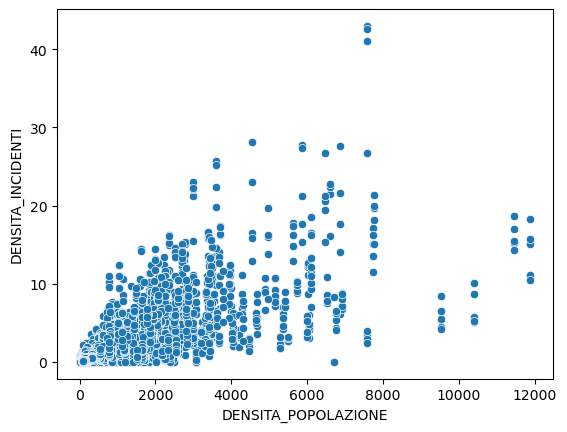

In [71]:
sns.scatterplot(data=df_incidenti,x="DENSITA_POPOLAZIONE",y="DENSITA_INCIDENTI")

plt.show()

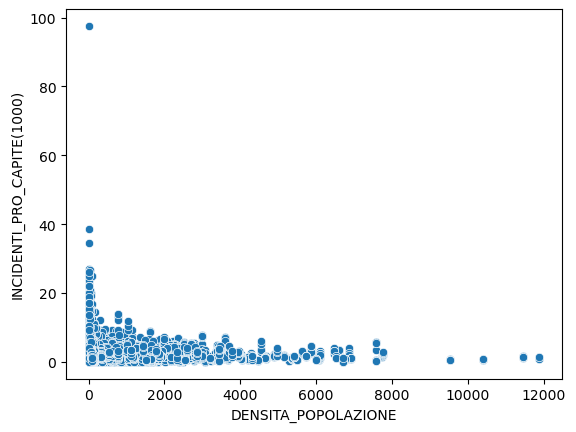

In [72]:
sns.scatterplot(data=df_incidenti,x="DENSITA_POPOLAZIONE",y="INCIDENTI_PRO_CAPITE(1000)")
plt.show()

#I valori più elevati del tasso di incidenti per 1000 abitanti sono concentrati nei comuni con popolazione estremamente ridotta. 
#In questi casi il tasso risulta particolarmente sensibile a piccole variazioni nel numero assoluto di incidenti e residenti,
#producendo valori estremi che non necessariamente rappresentano un livello di rischio maggiore rispetto ai comuni più popolosi.


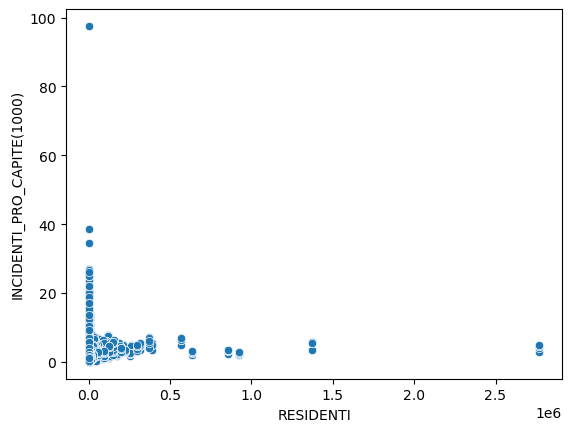

In [73]:
sns.scatterplot(data=df_incidenti,x="RESIDENTI",y="INCIDENTI_PRO_CAPITE(1000)")

plt.show()


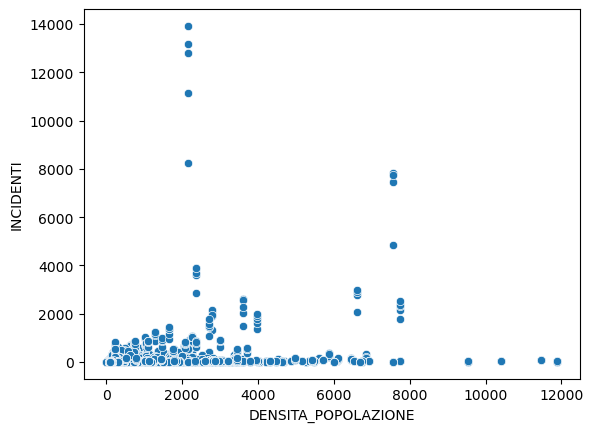

In [74]:
sns.scatterplot(data=df_incidenti,x="DENSITA_POPOLAZIONE",y="OBS_VALUE")
plt.ylabel("INCIDENTI")
plt.show()


# CREAZIONE DF SUI COMUNI (aggregazione AA 20-24)

In [75]:
df_comuni_incidenti_total=df_incidenti.drop(["INCIDENTI_PRO_CAPITE(1000)", "DENSITA_INCIDENTI", "DENSITA_POPOLAZIONE"], axis=1)
df_comuni_incidenti_total= (df_comuni_incidenti_total.groupby(["ID_COMUNE", "COMUNE"], as_index=False).agg({"OBS_VALUE": "sum",
                                                                                                               "RESIDENTI": "first",
                                                                                                               "SUPERFICIE (KMQ)": "first"})) 

#Ricreo le colonne sulla base del nuovo df in maniera tale che non vengano aggregate
df_comuni_incidenti_total["DENSITA_POPOLAZIONE"] = (df_comuni_incidenti_total["RESIDENTI"]/ df_comuni_incidenti_total["SUPERFICIE (KMQ)"])
df_comuni_incidenti_total["DENSITA_INCIDENTI"] = (df_comuni_incidenti_total["OBS_VALUE"]/ df_comuni_incidenti_total["SUPERFICIE (KMQ)"])
df_comuni_incidenti_total["INCIDENTI_PRO_CAPITE(1000)"] = (df_comuni_incidenti_total["OBS_VALUE"]/ df_comuni_incidenti_total["RESIDENTI"]) * 1000

df_comuni_incidenti_total.to_csv("df_clean/df_comuni_incidenti_total.csv",index=False)

# df_comuni_incidenti_total: -1 riga è 1 comune con relativi dati nel periodo compreso (aggregato) dal 2020 al 2024, 
# 				             -valori sono sommati solo quelli degli incidenti assoluti
#                            -superficie e residenti si presume siano rimasti costanti
# 				             -colonne con parametri densità popolazione, densità incidenti, incidenti
# 					                pro capite rifatte sulla base dell' aggregazione

df_comuni_incidenti_total.sort_values(by="INCIDENTI_PRO_CAPITE(1000)", ascending=False)



,ID_COMUNE,COMUNE,OBS_VALUE,RESIDENTI,SUPERFICIE (KMQ),DENSITA_POPOLAZIONE,DENSITA_INCIDENTI,INCIDENTI_PRO_CAPITE(1000)
153,1157,Moncenisio,6,41,4.5007,9.109694,1.333126,146.341463
486,4006,Argentera,6,78,76.2591,1.022829,0.078679,76.923077
5516,66083,Rocca Pia,13,181,44.9610,4.025711,0.289139,71.823204
1498,13030,Brienno,24,335,8.9720,37.338386,2.674989,71.641791
2712,21065,Ponte Gardena/Waidbruck,14,201,2.3282,86.332789,6.013229,69.651741
...,...,...,...,...,...,...,...,...
7059,91068,Osidda,0,223,25.6759,8.685187,0.000000,0.000000
4928,61045,Liberi,0,1061,17.5891,60.321449,0.000000,0.000000
5028,62041,Molinara,0,1484,24.1636,61.414690,0.000000,0.000000
5002,62015,Casalduni,0,1242,23.3398,53.213824,0.000000,0.000000


In [76]:
#i microcomuni più che definirli outlier per quanto riguarda incidenti pro capite li definirei anomalie
#è normale che se incidenti pro capite siano definiti come (incidenti/tot residenti)x1000 chi ha meno residenti 
#ha indice più alto

In [77]:
print(df_comuni_incidenti_total.info())
print("-------------------------------")
print("Numero di ID unici:", df_comuni_incidenti_total["ID_COMUNE"].nunique())
print("-------------------------------")
print(df_comuni_incidenti_total.duplicated().sum())


<class 'pandas.DataFrame'>
RangeIndex: 7903 entries, 0 to 7902
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID_COMUNE                   7903 non-null   int64  
 1   COMUNE                      7903 non-null   str    
 2   OBS_VALUE                   7903 non-null   int64  
 3   RESIDENTI                   7903 non-null   int64  
 4   SUPERFICIE (KMQ)            7903 non-null   float64
 5   DENSITA_POPOLAZIONE         7903 non-null   float64
 6   DENSITA_INCIDENTI           7903 non-null   float64
 7   INCIDENTI_PRO_CAPITE(1000)  7903 non-null   float64
dtypes: float64(4), int64(3), str(1)
memory usage: 494.1 KB
None
-------------------------------
Numero di ID unici: 7903
-------------------------------
0
